# Lab 2: Python Basics

**课程**：经济与商务实证研究方法（RMEB） 2026 Spring  
**主题**：Python 入门与 VS Code 一体化工作流  
**定位**：Week 2 计算环境搭建的配套实验

## 学习目标

完成本 notebook 后，你应该能够：

1. 在 VS Code 的 Jupyter 环境中直接运行 Python。
2. 理解 Python 变量、列表、字典和函数的基本用法。
3. 用 pandas 处理一个简单表格。
4. 固定随机种子并生成随机样本。
5. 画出一个基础直方图，并理解 Python 为什么适合作为研究胶水语言。

## 为什么要在 VS Code 里学 Python？

这门课不希望你在不同软件之间来回切换。更高效的方式是：

- 在 **VS Code** 里写代码、记笔记、看输出。
- 用 **Copilot** 做行内补全。
- 用 **Claude Code** 帮你规划、解释、重构和检查代码。
- 把 notebook 当成可执行讲义，而不是临时草稿。

**核心理念**：学生学习的不只是语言本身，更是一种更高效、更 AI-native 的研究工作流。

## 环境要求

运行本 notebook 前，请确保：

- VS Code 已安装 Jupyter 扩展。
- 当前 notebook 连接到 Python kernel。
- 环境中已安装 `numpy`、`pandas`、`matplotlib`。

这份材料的目标不是让你回到单独的软件界面里，而是在统一界面中把代码、解释和 AI 协作放在一起。

In [1]:
import sys
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Python version:', sys.version.split()[0])
print('NumPy version:', np.__version__)
print('pandas version:', pd.__version__)

Python version: 3.13.3
NumPy version: 2.4.4
pandas version: 3.0.2


## 1. 基本语法

Python 对初学者友好的原因之一，是它的语法比较直观。

In [2]:
course_name = 'RMEB'
week = 2
scores = [88, 92, 79, 95]
student = {'name': 'Alice', 'group': 3}

def square(x):
    return x ** 2

print('课程：', course_name)
print('第', week, '周')
print('scores =', scores)
print('student =', student)
print('5 的平方 =', square(5))

课程： RMEB
第 2 周
scores = [88, 92, 79, 95]
student = {'name': 'Alice', 'group': 3}
5 的平方 = 25


## 2. 表格数据

pandas 是 Python 做数据处理时最常用的基础工具之一。

In [5]:
df = pd.DataFrame(
    {
        'id': [1, 1, 2, 2, 3, 3],
        'year': [2024, 2025, 2024, 2025, 2024, 2025],
        'treatment': [0, 1, 0, 0, 1, 1],
        'outcome': [10.2, 11.5, 9.8, 10.0, 12.1, 12.7],
    }
)

df['outcome_gap'] = df['outcome'] - df['outcome'].mean()
df_2025 = df[df['year'] == 2025]

print('完整数据：')
display(df)
print('2025 年样本：')
display(df_2025)

完整数据：


,id,year,treatment,outcome,outcome_gap
0,1,2024,0,10.2,-0.85
1,1,2025,1,11.5,0.45
2,2,2024,0,9.8,-1.25
3,2,2025,0,10.0,-1.05
4,3,2024,1,12.1,1.05
5,3,2025,1,12.7,1.65


2025 年样本：


,id,year,treatment,outcome,outcome_gap
1,1,2025,1,11.5,0.45
3,2,2025,0,10.0,-1.05
5,3,2025,1,12.7,1.65


## 3. 随机数与可重复性

固定随机种子是做 Monte Carlo 模拟和课堂演示的基本习惯。

样本均值 = 0.0193
样本标准差 = 0.9792


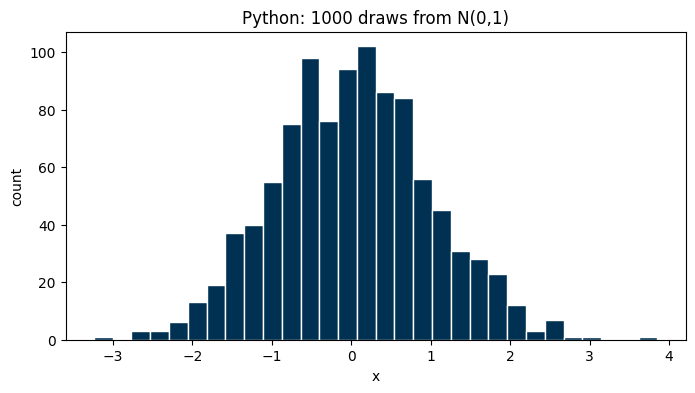

In [6]:
np.random.seed(42)
x = np.random.randn(1000)

print('样本均值 =', round(x.mean(), 4))
print('样本标准差 =', round(x.std(ddof=1), 4))

plt.figure(figsize=(8, 4))
plt.hist(x, bins=30, color='#003153', edgecolor='white')
plt.title('Python: 1000 draws from N(0,1)')
plt.xlabel('x')
plt.ylabel('count')
plt.show()

## 4. 循环与控制流

Python 的循环语法清晰直观，是自动化重复操作的基础。

In [ ]:
# --- for 循环 ---
# 遍历列表
fruits = ["苹果", "香蕉", "橙子"]
for fruit in fruits:
    print(f"我喜欢吃{fruit}")

# 使用 range 生成数字序列
total = 0
for i in range(1, 11):
    total += i
print(f"1到10的和 = {total}")

# enumerate: 同时获取索引和值
for idx, fruit in enumerate(fruits):
    print(f"第{idx+1}个: {fruit}")

# --- while 循环 ---
n = 1
while n <= 5:
    print(f"当前 n = {n}")
    n += 1

# --- 列表推导式 (List Comprehension) —— Python 的特色循环 ---
squares = [x**2 for x in range(1, 11)]
print(f"平方数: {squares}")

# 带条件的列表推导
even_squares = [x**2 for x in range(1, 11) if x % 2 == 0]
print(f"偶数的平方: {even_squares}")

# 字典推导式
word_lengths = {w: len(w) for w in ["Python", "Stata", "R"]}
print(f"单词长度: {word_lengths}")

## 5. 函数的写法

函数是代码复用的核心。Python 使用 `def` 定义函数，支持默认参数、可变参数和匿名函数。

In [ ]:
# --- 基本函数 ---
def greet(name):
    """向某人打招呼"""
    return f"你好，{name}！"

print(greet("同学"))

# --- 带默认参数的函数 ---
def power(base, exp=2):
    """计算幂，默认平方"""
    return base ** exp

print(power(3))       # 9
print(power(2, 10))   # 1024

# --- 返回多个值 ---
def stats(numbers):
    """返回均值和标准差"""
    import numpy as np
    return np.mean(numbers), np.std(numbers)

data = [85, 90, 78, 92, 88]
mean_val, std_val = stats(data)
print(f"均值={mean_val:.1f}, 标准差={std_val:.1f}")

# --- *args 和 **kwargs: 可变参数 ---
def flexible_sum(*args):
    """接受任意多个数字"""
    return sum(args)

print(flexible_sum(1, 2, 3, 4, 5))  # 15

# --- lambda 匿名函数 ---
square = lambda x: x ** 2
print(f"5的平方 = {square(5)}")

# lambda 常用于排序
students = [("张三", 85), ("李四", 92), ("王五", 78)]
students_sorted = sorted(students, key=lambda s: s[1], reverse=True)
print(f"成绩排名: {students_sorted}")

## 6. 高级用法入门

Python 最强大的特性之一是其丰富的高级语法糖和生态系统。

In [ ]:
# === 高级特性 1: 装饰器 (Decorator) ===
# 装饰器可以在不修改函数代码的情况下增加功能
import time

def timer(func):
    """计时装饰器：自动测量函数运行时间"""
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - start
        print(f"[{func.__name__}] 耗时 {elapsed:.4f} 秒")
        return result
    return wrapper

@timer
def slow_sum(n):
    return sum(range(n))

slow_sum(1_000_000)

# === 高级特性 2: 生成器 (Generator) ===
# 生成器用 yield 逐个产出值，节省内存
def fibonacci(n):
    """生成前 n 个斐波那契数"""
    a, b = 0, 1
    for _ in range(n):
        yield a
        a, b = b, a + b

fib_list = list(fibonacci(10))
print(f"斐波那契前10项: {fib_list}")

# === 高级特性 3: 上下文管理器 (Context Manager) ===
# with 语句自动管理资源（文件打开/关闭）
with open("demo_output.txt", "w", encoding="utf-8") as f:
    f.write("这是一个用 with 语句写入的文件\n")
    f.write("文件会在 with 块结束后自动关闭\n")

# 读取验证
with open("demo_output.txt", "r", encoding="utf-8") as f:
    print(f.read())

# === 高级特性 4: 类型提示 (Type Hints) ===
# Python 3.5+ 支持类型提示，提高代码可读性
from typing import List, Tuple

def compute_returns(prices: List[float]) -> List[float]:
    """计算收益率序列"""
    return [(prices[i] - prices[i-1]) / prices[i-1] 
            for i in range(1, len(prices))]

stock_prices = [100.0, 102.5, 101.0, 105.0, 103.5]
returns = compute_returns(stock_prices)
print(f"收益率: {[f'{r:.2%}' for r in returns]}")

import os
os.remove("demo_output.txt")  # 清理临时文件

## ✨ Python 杀手锏预览：机器学习流水线

Python 是机器学习的通用语言。**scikit-learn** 让从数据到模型评估的完整流水线只需几行代码——多模型对比、交叉验证、自动评分一气呵成。

> 💡 **研究中的组合优势**：Python 训练预测模型 + Stata 做因果推断 + R 做出版级图表，这是现代实证研究的标准配置。

In [2]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 25.5 kB/s  0:05:56m0:00:0800:18
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [ ]:
#pip install scikit-learn
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# 模拟非线性 DGP：Y = X1 + X2² + X1·X3 + 噪声
np.random.seed(42)
n = 500
X = np.random.randn(n, 5)
y = X[:, 0] + X[:, 1]**2 + X[:, 0] * X[:, 2] + np.random.randn(n) * 0.5

# 三个模型 × 五折交叉验证 — 几行代码完成模型选择
models = {
    "线性回归 (OLS)": LinearRegression(),
    "随机森林":       RandomForestRegressor(n_estimators=100, random_state=42),
    "梯度提升":       GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print("模型对比（5-fold CV R²）:")
print("-" * 40)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"{name:15s}  R² = {scores.mean():.3f} ± {scores.std():.3f}")

print("\n💡 非线性 DGP 下，树模型完胜 OLS — 这就是机器学习的价值")

ModuleNotFoundError: No module named 'sklearn'

## 4. 练习

请完成以下练习：

1. 把 `x` 改成均值为 5、标准差为 2 的正态样本。
2. 在 `df` 中新增一列 `treated_outcome = treatment * outcome`。
3. 试着让 Copilot 帮你把这份 notebook 扩展成一个小型 OLS 演示。

In [7]:
# TODO: 在这里写你的练习代码